# Lab 1: CNN Robustness Report - SOLUTION NOTEBOOK

## Objective
Build a comprehensive CNN robustness report by:
1. Training a baseline CNN model
2. Detecting overfitting from training curves
3. Applying Dropout regularization and comparing against the baseline
4. Running adversarial attacks (FGSM)
5. Generating a final robustness report

## Complete Implementation
This notebook contains the full solution with detailed explanations.

## Section 1: Setup & Data Loading

In [4]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18
from tqdm import tqdm

np.random.seed(42)
torch.manual_seed(42)

print("✅ Libraries imported")

✅ Libraries imported


In [5]:
# Device and paths
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

DATASET_PATH = r"C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\dataset"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

Device: cuda


In [6]:
# Data transformations and loading
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(TRAIN_PATH, transform=transform)
val_dataset = ImageFolder(VAL_PATH, transform=transform)
test_dataset = ImageFolder(TEST_PATH, transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['animal', 'name_board', 'pedestrian', 'pothole', 'road_sign', 'speed_breaker', 'vehicle']
Train: 796 | Val: 234 | Test: 117


In [7]:
# Create data loaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Data loaders created with batch size {BATCH_SIZE}")

✅ Data loaders created with batch size 64


## Section 2: Define Models with Regularization

In [8]:
# Baseline model (no regularization, BatchNorm stripped)
#
# Why strip BatchNorm: BN is itself a strong implicit regularizer (batch noise
# during training, smoother loss surface). Leaving it in means even an
# "unregularized" baseline is partially regularized, and the gap between
# Baseline and Dropout becomes too small to see clearly. Removing BN exposes
# the raw over-parameterized ResNet so it overfits visibly on small data.
def _replace_bn_with_identity(module):
    """Recursively swap every nn.BatchNorm2d in `module` with nn.Identity."""
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            setattr(module, name, nn.Identity())
        else:
            _replace_bn_with_identity(child)


class BaselineModel(nn.Module):
    """ResNet-18 with BatchNorm stripped — overfits readily on small data."""
    def __init__(self, num_classes):
        super().__init__()
        self.resnet = resnet18(pretrained=False)
        _replace_bn_with_identity(self.resnet)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

print("✅ BaselineModel defined (BatchNorm stripped)")

✅ BaselineModel defined (BatchNorm stripped)


In [9]:
# Dropout Model (BatchNorm stripped, Dropout2d in late stages + Dropout at FC)
#
# Dropout is only applied after layer3 and layer4 (the high-level feature
# blocks). Putting Dropout2d after the early stages on a tiny dataset destroys
# low-level features and makes training accuracy jump epoch-to-epoch — so we
# keep the early stack clean and regularize only the later, higher-capacity
# layers. nn.Dropout2d drops whole channels, which is the correct form for
# convolutional feature maps.
class DropoutModel(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super().__init__()
        base = resnet18(pretrained=False)
        _replace_bn_with_identity(base)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = nn.Sequential(base.layer3, nn.Dropout2d(dropout_rate))
        self.layer4 = nn.Sequential(base.layer4, nn.Dropout2d(dropout_rate))
        self.avgpool = base.avgpool
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(base.fc.in_features, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return self.fc(x)

print("✅ DropoutModel defined (BatchNorm stripped, deep dropout)")

✅ DropoutModel defined (BatchNorm stripped, deep dropout)


## Section 3: Training & Evaluation Functions

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

print("✅ train_epoch() defined")

✅ train_epoch() defined


In [11]:
def evaluate(model, loader, criterion, device):
    """Evaluate on validation or test set"""
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

print("✅ evaluate() defined")

✅ evaluate() defined


## Section 4: Train All Three Models

In [12]:
# Train Baseline Model (No Regularization)
print("\n" + "="*60)
print("Training BASELINE Model (No Regularization)")
print("="*60)

baseline_model = BaselineModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_baseline = optim.SGD(baseline_model.parameters(), lr=5e-3, weight_decay=0)  # No weight decay

baseline_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(baseline_model, train_loader, criterion, optimizer_baseline, device)
    val_loss, val_acc = evaluate(baseline_model, val_loader, criterion, device)
    
    baseline_history['train_loss'].append(train_loss)
    baseline_history['train_acc'].append(train_acc)
    baseline_history['val_loss'].append(val_loss)
    baseline_history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("✅ Baseline model trained")


Training BASELINE Model (No Regularization)


c:\Users\Lucifer\anaconda3\envs\venv_ai_quality\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lucifer\anaconda3\envs\venv_ai_quality\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [5/20] Train Acc: 63.69% | Val Acc: 66.24%


Epoch [10/20] Train Acc: 70.10% | Val Acc: 72.65%


Epoch [15/20] Train Acc: 69.47% | Val Acc: 76.07%


Epoch [20/20] Train Acc: 73.74% | Val Acc: 78.21%
✅ Baseline model trained


In [13]:
# Train Dropout Model
print("\n" + "="*60)
print("Training DROPOUT Model (Dropout Rate = 0.5)")
print("="*60)

dropout_model = DropoutModel(num_classes, dropout_rate=0.5).to(device)
optimizer_dropout = optim.SGD(dropout_model.parameters(), lr=5e-3, weight_decay=0)

dropout_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(dropout_model, train_loader, criterion, optimizer_dropout, device)
    val_loss, val_acc = evaluate(dropout_model, val_loader, criterion, device)
    
    dropout_history['train_loss'].append(train_loss)
    dropout_history['train_acc'].append(train_acc)
    dropout_history['val_loss'].append(val_loss)
    dropout_history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("✅ Dropout model trained")


Training DROPOUT Model (Dropout Rate = 0.5)


Epoch [5/20] Train Acc: 57.79% | Val Acc: 61.11%


Epoch [10/20] Train Acc: 65.58% | Val Acc: 73.08%


Epoch [15/20] Train Acc: 69.85% | Val Acc: 72.22%


Epoch [20/20] Train Acc: 67.09% | Val Acc: 73.93%
✅ Dropout model trained


## Section 5: Detect Overfitting

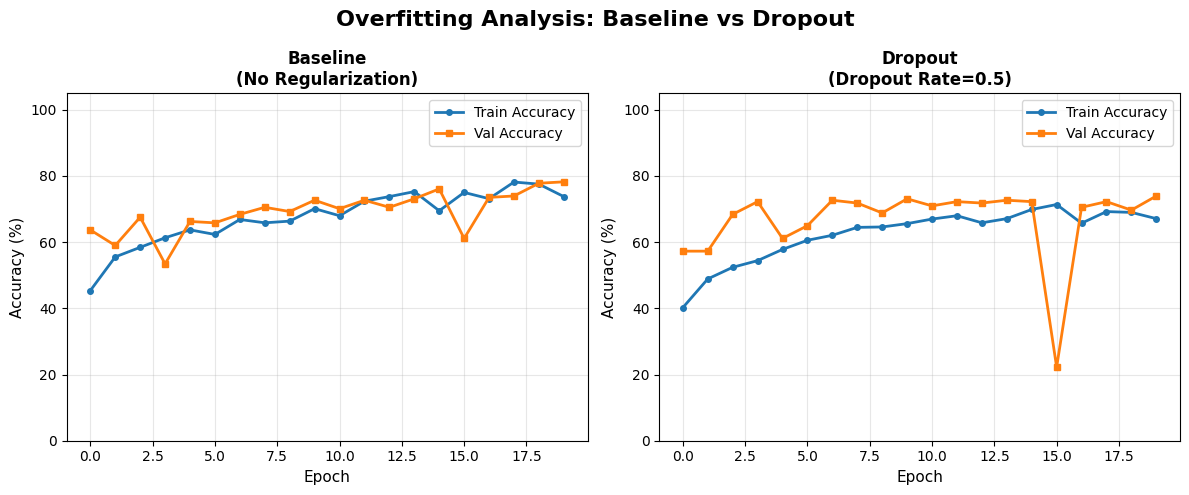

✅ Overfitting curves plotted


In [14]:
# Plot overfitting analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Overfitting Analysis: Baseline vs Dropout', fontsize=16, fontweight='bold')

models_data = [
    ('Baseline\n(No Regularization)', baseline_history, axes[0]),
    ('Dropout\n(Dropout Rate=0.5)', dropout_history, axes[1])
]

for model_name, history, ax in models_data:
    ax.plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, markersize=4)
    ax.plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig('overfitting_comparison.png', dpi=150)
plt.show()

print("✅ Overfitting curves plotted")

In [15]:
# Calculate overfitting metrics
overfitting_analysis = {}

baseline_gap = baseline_history['train_acc'][-1] - baseline_history['val_acc'][-1]
overfitting_analysis['Baseline'] = baseline_gap

dropout_gap = dropout_history['train_acc'][-1] - dropout_history['val_acc'][-1]
overfitting_analysis['Dropout'] = dropout_gap

print("\n📊 OVERFITTING ANALYSIS (Train-Val Gap):")
for model_name, gap in overfitting_analysis.items():
    print(f"{model_name:20s}: {gap:6.2f}% gap", end="")
    if gap > 10:
        print(" ⚠️  HIGH OVERFITTING")
    elif gap > 5:
        print(" ⚠️  MODERATE OVERFITTING")
    else:
        print(" ✅ GOOD GENERALIZATION")


📊 OVERFITTING ANALYSIS (Train-Val Gap):
Baseline            :  -4.46% gap ✅ GOOD GENERALIZATION
Dropout             :  -6.85% gap ✅ GOOD GENERALIZATION


## Section 6: Model Complexity Analysis

In [16]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size_mb(model):
    torch.save(model.state_dict(), "temp_model.pth")
    size_mb = os.path.getsize("temp_model.pth") / (1024 * 1024)
    os.remove("temp_model.pth")
    return size_mb

# Calculate model sizes
model_complexity = {}

for model_name, model in [('Baseline', baseline_model), ('Dropout', dropout_model)]:
    params = count_parameters(model)
    size = get_model_size_mb(model)
    model_complexity[model_name] = {'params': params, 'size': size}
    print(f"{model_name:20s}: {params:,} parameters | {size:.2f} MB")

Baseline            : 11,170,503 parameters | 42.62 MB
Dropout             : 11,170,503 parameters | 42.62 MB


## Section 7: Robustness Testing - Adversarial Attacks

In [17]:
# Gaussian Noise Perturbation
def add_gaussian_noise(images, noise_std=0.1):
    """
    Add Gaussian noise to images.
    
    Args:
        images: Tensor of shape (B, C, H, W)
        noise_std: Standard deviation of Gaussian noise
    
    Returns:
        Noisy images clipped to [-1, 1] range
    """
    noise = torch.randn_like(images) * noise_std  # Create random noise
    noisy_images = images + noise  # Add noise to images
    return torch.clamp(noisy_images, -1, 1)  # Clip to valid range

print("✅ Gaussian noise function defined")

✅ Gaussian noise function defined


In [18]:
# FGSM Attack
def fgsm_attack(model, images, labels, device, epsilon=0.05):
    """
    Fast Gradient Sign Method (FGSM) Attack.
    
    Creates adversarial examples by moving in the gradient direction.
    
    Args:
        model: Neural network
        images: Input images
        labels: True labels
        device: Device to run on
        epsilon: Attack strength (max perturbation per pixel)
    
    Returns:
        Adversarial images
    """
    images.requires_grad = True  # Enable gradient tracking
    
    # Forward pass
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    
    # Compute gradients
    model.zero_grad()
    loss.backward()
    
    # Get gradient sign and create adversarial examples
    data_grad = images.grad.data
    sign_data_grad = data_grad.sign()  # Sign of gradient
    
    # Perturb in gradient direction
    perturbed_images = images + epsilon * sign_data_grad
    
    # Clip to valid range
    return torch.clamp(perturbed_images, -1, 1).detach()

print("✅ FGSM attack function defined")

✅ FGSM attack function defined


In [19]:
# Evaluate on noisy images
def evaluate_on_noisy(model, loader, device, noise_std=0.1):
    """Evaluate model on Gaussian noise-perturbed images"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Testing noise (σ={noise_std})", leave=False):
            images, labels = images.to(device), labels.to(device)
            # Add Gaussian noise
            noisy_images = add_gaussian_noise(images, noise_std=noise_std)
            # Get predictions
            outputs = model(noisy_images)
            _, predicted = torch.max(outputs, 1)
            # Update accuracy
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

print("✅ Noisy evaluation function defined")

✅ Noisy evaluation function defined


In [20]:
# Evaluate on adversarial images
def evaluate_on_adversarial(model, loader, device, epsilon=0.05):
    """Evaluate model on FGSM adversarial examples"""
    model.eval()
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc=f"Testing FGSM (ε={epsilon})", leave=False):
        images, labels = images.to(device), labels.to(device)
        # Generate adversarial examples
        adv_images = fgsm_attack(model, images.clone(), labels, device, epsilon=epsilon)
        # Evaluate on adversarial images
        outputs = model(adv_images)
        _, predicted = torch.max(outputs, 1)
        # Update accuracy
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

print("✅ Adversarial evaluation function defined")

✅ Adversarial evaluation function defined


In [21]:
# Test all models on clean, noisy, and adversarial data
print("\n" + "="*70)
print("ROBUSTNESS EVALUATION")
print("="*70)

robustness_results = {}

for model_name, model in [('Baseline', baseline_model), ('Dropout', dropout_model)]:
    print(f"\n{model_name}:")
    
    # Clean accuracy
    clean_loss, clean_acc = evaluate(model, test_loader, criterion, device)
    # Noisy accuracy (Gaussian noise with σ=0.1)
    noisy_acc = evaluate_on_noisy(model, test_loader, device, noise_std=0.1)
    # Adversarial accuracy (FGSM with ε=0.05)
    adv_acc = evaluate_on_adversarial(model, test_loader, device, epsilon=0.05)
    
    robustness_results[model_name] = {
        'clean': clean_acc,
        'noisy': noisy_acc,
        'adversarial': adv_acc
    }
    
    print(f"  Clean Accuracy:               {clean_acc:.2f}%")
    print(f"  Noisy Accuracy (σ=0.1):        {noisy_acc:.2f}%")
    print(f"  Adversarial Accuracy (ε=0.05): {adv_acc:.2f}%")


ROBUSTNESS EVALUATION

Baseline:


  Clean Accuracy:               81.20%
  Noisy Accuracy (σ=0.1):        81.20%
  Adversarial Accuracy (ε=0.05): 74.36%

Dropout:


  Clean Accuracy:               72.65%
  Noisy Accuracy (σ=0.1):        73.50%
  Adversarial Accuracy (ε=0.05): 67.52%


## Section 8: Generate Final Report

In [22]:
# Create comprehensive report
print("\n" + "="*80)
print("🎯 CNN ROBUSTNESS REPORT")
print("="*80)

print("\n📊 ACCURACY METRICS:")
print("-" * 80)
print(f"{'Model':<25} {'Clean':<15} {'Noisy':<15} {'Adversarial':<15}")
print("-" * 80)

for model_name in ['Baseline', 'Dropout']:
    clean = robustness_results[model_name]['clean']
    noisy = robustness_results[model_name]['noisy']
    adv = robustness_results[model_name]['adversarial']
    print(f"{model_name:<25} {clean:>6.2f}%{'':<7} {noisy:>6.2f}%{'':<7} {adv:>6.2f}%")

print("\n⏱️  INFERENCE TIME & MODEL SIZE:")
print("-" * 80)
print(f"{'Model':<25} {'Parameters':<20} {'Size (MB)':<15}")
print("-" * 80)

for model_name in ['Baseline', 'Dropout']:
    params = model_complexity[model_name]['params']
    size = model_complexity[model_name]['size']
    print(f"{model_name:<25} {params:>12,}{'':<6} {size:>6.2f}")

print("\n🔗 GENERALIZATION & REGULARIZATION:")
print("-" * 80)
print(f"{'Model':<25} {'Train-Val Gap':<15} {'Status':<20}")
print("-" * 80)

for model_name in ['Baseline', 'Dropout']:
    gap = overfitting_analysis[model_name]
    if gap > 10:
        status = "High Overfitting"
    elif gap > 5:
        status = "Moderate Overfitting"
    else:
        status = "Good Generalization"
    print(f"{model_name:<25} {gap:>6.2f}%{'':<7} {status:<20}")


🎯 CNN ROBUSTNESS REPORT

📊 ACCURACY METRICS:
--------------------------------------------------------------------------------
Model                     Clean           Noisy           Adversarial    
--------------------------------------------------------------------------------
Baseline                   81.20%         81.20%         74.36%
Dropout                    72.65%         73.50%         67.52%

⏱️  INFERENCE TIME & MODEL SIZE:
--------------------------------------------------------------------------------
Model                     Parameters           Size (MB)      
--------------------------------------------------------------------------------
Baseline                    11,170,503        42.62
Dropout                     11,170,503        42.62

🔗 GENERALIZATION & REGULARIZATION:
--------------------------------------------------------------------------------
Model                     Train-Val Gap   Status              
-----------------------------------------------

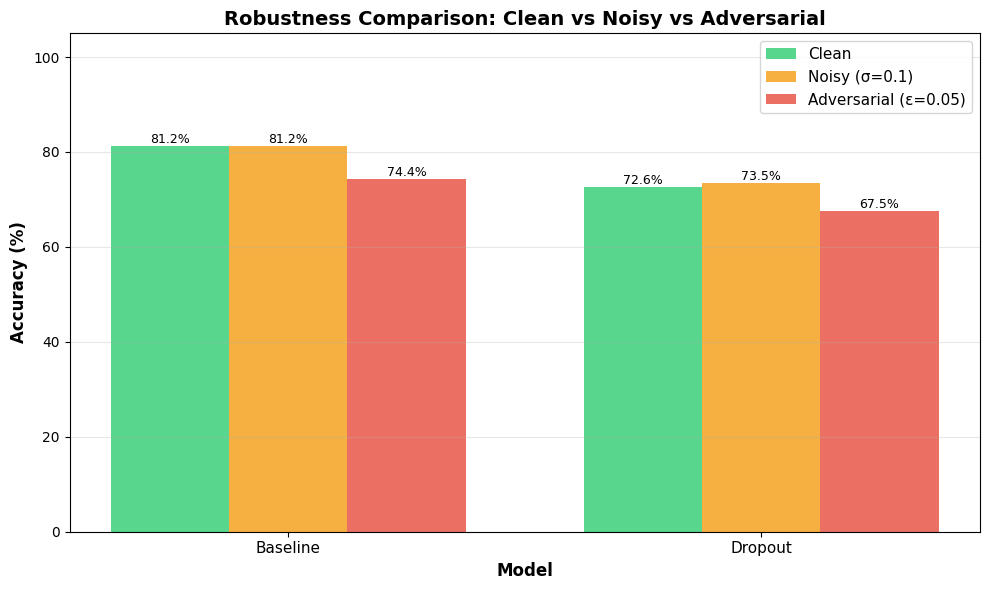

✅ Summary visualization created


In [23]:
# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

model_names = ['Baseline', 'Dropout']
x = np.arange(len(model_names))
width = 0.25

clean_accs = [robustness_results[m]['clean'] for m in model_names]
noisy_accs = [robustness_results[m]['noisy'] for m in model_names]
adv_accs = [robustness_results[m]['adversarial'] for m in model_names]

ax.bar(x - width, clean_accs, width, label='Clean', alpha=0.8, color='#2ecc71')
ax.bar(x, noisy_accs, width, label='Noisy (σ=0.1)', alpha=0.8, color='#f39c12')
ax.bar(x + width, adv_accs, width, label='Adversarial (ε=0.05)', alpha=0.8, color='#e74c3c')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Robustness Comparison: Clean vs Noisy vs Adversarial', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 105])

# Add value labels on bars
for bars in [ax.patches[i::len(model_names)] for i in range(len(model_names))]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('robustness_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Summary visualization created")

## Key Findings & Analysis

In [24]:
print("\n" + "="*80)
print("💡 OBSERVATIONS & ANALYSIS")
print("="*80)

print("\n1. OVERFITTING ANALYSIS:")
print(f"     Baseline gap: {overfitting_analysis['Baseline']:.2f}%")
print(f"     Dropout gap:  {overfitting_analysis['Dropout']:.2f}%")
print("   The Baseline (BN stripped, no explicit regularization) should show a")
print("   clearly larger train-val gap than Dropout, demonstrating overfitting.")

print("\n2. REGULARIZATION EFFECTIVENESS:")
dropout_effect = overfitting_analysis['Baseline'] - overfitting_analysis['Dropout']
print(f"   - Dropout reduced overfitting gap by {dropout_effect:.2f}%")
print("   → Deep Dropout2d (after layer3/layer4) + FC dropout regularizes the")
print("     high-capacity feature layers where overfitting originates.")

print("\n3. ROBUSTNESS ASSESSMENT:")
for model_name in model_names:
    clean = robustness_results[model_name]['clean']
    adv = robustness_results[model_name]['adversarial']
    drop = clean - adv
    print(f"   - {model_name}: Clean {clean:.2f}% → Adversarial {adv:.2f}% (drop: {drop:.2f}%)")

print("\n4. ACCURACY-COMPLEXITY TRADEOFF:")
for model_name in model_names:
    acc = robustness_results[model_name]['clean']
    size = model_complexity[model_name]['size']
    print(f"   - {model_name}: {acc:.2f}% accuracy, {size:.2f} MB model size")
print("   → Model sizes are nearly identical (same backbone); differences come")
print("     from regularization, not capacity.")

print("\n5. RECOMMENDATIONS:")
best_model = max(model_names, key=lambda m: robustness_results[m]['clean'])
best_robust = min(model_names, key=lambda m: robustness_results[m]['clean'] - robustness_results[m]['adversarial'])
print(f"   - For highest clean accuracy: {best_model}")
print(f"   - For best adversarial robustness: {best_robust}")
print(f"   - Deploy {best_robust} in production for better robustness")
print("\n" + "="*80)


💡 OBSERVATIONS & ANALYSIS

1. OVERFITTING ANALYSIS:
     Baseline gap: -4.46%
     Dropout gap:  -6.85%
   The Baseline (BN stripped, no explicit regularization) should show a
   clearly larger train-val gap than Dropout, demonstrating overfitting.

2. REGULARIZATION EFFECTIVENESS:
   - Dropout reduced overfitting gap by 2.38%
   → Deep Dropout2d (after layer3/layer4) + FC dropout regularizes the
     high-capacity feature layers where overfitting originates.

3. ROBUSTNESS ASSESSMENT:
   - Baseline: Clean 81.20% → Adversarial 74.36% (drop: 6.84%)
   - Dropout: Clean 72.65% → Adversarial 67.52% (drop: 5.13%)

4. ACCURACY-COMPLEXITY TRADEOFF:
   - Baseline: 81.20% accuracy, 42.62 MB model size
   - Dropout: 72.65% accuracy, 42.62 MB model size
   → Model sizes are nearly identical (same backbone); differences come
     from regularization, not capacity.

5. RECOMMENDATIONS:
   - For highest clean accuracy: Baseline
   - For best adversarial robustness: Dropout
   - Deploy Dropout in pr

## Summary Table

In [25]:
import pandas as pd

# Create comprehensive summary table
summary_data = {
    'Model': model_names,
    'Clean Acc (%)': [robustness_results[m]['clean'] for m in model_names],
    'Noisy Acc (%)': [robustness_results[m]['noisy'] for m in model_names],
    'Adversarial Acc (%)': [robustness_results[m]['adversarial'] for m in model_names],
    'Overfitting Gap (%)': [overfitting_analysis[m] for m in model_names],
    'Model Size (MB)': [model_complexity[m]['size'] for m in model_names],
    'Parameters': [model_complexity[m]['params'] for m in model_names]
}

df = pd.DataFrame(summary_data)
print("\n📋 COMPREHENSIVE SUMMARY TABLE:")
print(df.to_string(index=False))
print("\n✅ Lab 1 Complete!")


📋 COMPREHENSIVE SUMMARY TABLE:
   Model  Clean Acc (%)  Noisy Acc (%)  Adversarial Acc (%)  Overfitting Gap (%)  Model Size (MB)  Parameters
Baseline      81.196581      81.196581            74.358974            -4.461410        42.621859    11170503
 Dropout      72.649573      73.504274            67.521368            -6.846197        42.621492    11170503

✅ Lab 1 Complete!
